In [1]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['NEO4J_URI'] = "neo4j://44.202.197.250:7687"
os.environ['NEO4J_USERNAME'] = "neo4j"
os.environ['NEO4J_PASSWORD'] = "crime-laws-student"

In [2]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]
    db_outputs: list

graph_builder = StateGraph(State)

In [3]:
from neo4j import GraphDatabase, basic_auth

neo4j_uri = os.environ['NEO4J_URI']
neo4j_username = os.environ['NEO4J_USERNAME']
neo4j_password = os.environ['NEO4J_PASSWORD']

driver = GraphDatabase.driver(
    neo4j_uri,
    auth=basic_auth(neo4j_username, neo4j_password)
)

In [4]:
from neo4j.time import Date

def get_node_datatype(value):
    '''
    입력된 노드 Value의 데이터 타입을 반환하는 함수
    '''
    if isinstance(value, str):
        return 'STRING'
    elif isinstance(value, int):
        return 'INTEGER'
    elif isinstance(value, float):
        return 'FLOAT'
    elif isinstance(value, bool):
        return 'BOOLEAN'
    elif isinstance(value, list):
        return f'LIST[{get_node_datatype(value[0])}]' if value else "LIST"
    elif isinstance(value, Date):
        return 'DATE'
    else:
        return 'UNKNOWN'

In [5]:
def get_schema_dict():
    '''
    Graph DB의 정보를 받아 노드 및 관계의 프로퍼티를 추출하고 스키마 딕셔너리를 반환하는 함수
    '''
    with driver.session() as session:
        node_query = '''
        MATCH (n)
        WITH DISTINCT labels(n) AS node_labels, keys(n) AS property_keys, n
        UNWIND node_labels AS label
        UNWIND property_keys AS key
        RETURN label, key, n[key] AS sample_value
        '''
        nodes = session.run(node_query)

        rel_query = '''
        MATCH ()-[r]->()
        WITH DISTINCT type(r) AS rel_type, keys(r) AS property_keys, r
        UNWIND property_keys AS key
        RETURN rel_type, key, r[key] AS sample_value
        '''
        relationships = session.run(rel_query)
        
        rel_direction_query = '''
        MATCH (a)-[r]->(b)
        RETURN DISTINCT labels(a) AS start_label, type(r) AS rel_type, labels(b) AS end_label
        ORDER BY start_label, rel_type, end_label
        '''
        rel_directions = session.run(rel_direction_query)

        schema = {'nodes': {}, 'relationships': {}, 'relations': []}

        for record in nodes:
            label = record['label']
            key = record['key']
            sample_value = record['sample_value']
            inferred_type = get_node_datatype(sample_value)
            if label not in schema['nodes']:
                schema['nodes'][label] = {}
            schema['nodes'][label][key] = inferred_type
        
        for record in relationships:
            rel_type = record['rel_type']
            key = record['key']
            sample_value = record['sample_value']
            inferred_type = get_node_datatype(sample_value)
            if rel_type not in schema['relationships']:
                schema['relationships'][rel_type] = {}
            schema['relationships'][rel_type][key] = inferred_type
        
        for record in rel_directions:
            start_label = record['start_label'][0]
            rel_type = record['rel_type']
            end_label = record['end_label'][0]
            schema['relations'].append(f'(:{start_label})-[:{rel_type}]->(:{end_label})')
        
        return schema

def get_schema_str(schema):
    result = []

    result.append('Node properties:')
    for label, properties in schema['nodes'].items():
        props = ', '.join(f'{k}: {v}' for k, v in properties.items())
        result.append(f'{label} {{{props}}}')
    
    result.append('Relationship properties:')
    for rel_type, properties in schema['relationships'].items():
        props = ', '.join(f'{k}: {v}' for k, v in properties.items())
        result.append(f'{rel_type} {{{props}}}')

    result.append('The relationships:')
    for relation in schema['relations']:
        result.append(relation)
    
    return '\n'.join(result)

In [6]:
schema = get_schema_str(get_schema_dict())

In [7]:
print(schema)

Node properties:
Movie {url: STRING, runtime: INTEGER, revenue: INTEGER, budget: INTEGER, imdbRating: FLOAT, released: STRING, countries: LIST[STRING], languages: LIST[STRING], plot: STRING, imdbVotes: INTEGER, imdbId: STRING, year: INTEGER, poster: STRING, movieId: STRING, tmdbId: STRING, title: STRING}
Genre {name: STRING}
User {userId: STRING, name: STRING}
Actor {bornIn: STRING, born: DATE, died: DATE, tmdbId: STRING, imdbId: STRING, name: STRING, url: STRING, bio: STRING, poster: STRING}
Person {bornIn: STRING, born: DATE, died: DATE, tmdbId: STRING, imdbId: STRING, name: STRING, url: STRING, bio: STRING, poster: STRING}
Director {url: STRING, bornIn: STRING, bio: STRING, died: DATE, born: DATE, imdbId: STRING, name: STRING, poster: STRING, tmdbId: STRING}
Relationship properties:
RATED {rating: FLOAT, timestamp: INTEGER}
ACTED_IN {role: STRING}
DIRECTED {role: STRING}
The relationships:
(:Actor)-[:ACTED_IN]->(:Movie)
(:Actor)-[:DIRECTED]->(:Movie)
(:Actor)-[:ACTED_IN]->(:Movie)
(

In [8]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')

In [9]:
fewshot_examples = [
    "USER INPUT: 'Toy Story'에 어떤 배우들이 출연하나요?' QUERY: MATCH (a:Actor)-[:ACTED_IN]->(m:Movie) WHERE m.title = 'Toy Story' RETURN a.name",
    "USER INPUT: 'Toy Story의 평균 평점은 몇점인가요?' QUERY: MATCH (u:User)-[r:Rated]->(m:Movie) WHERE m.title = 'Toy Story' RETURN AVG(r.rating)",
]

In [10]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import AIMessage

GENERATE_SYSTEM_TEMPLATE = '''Given an input question, convert it to a Cypher query. No pre-amble.
Do not wrap the response in any backticks or anything else. Respond with a Cypher statement only!'''

GENERATE_USER_TEMPLATE = '''You are a Neo4j expert. Given an input question, create a syntactically correct Cypher query to run.
Do not wrap the response in any backticks or anything else. Respond with a Cypher statement only!
Here is the schema information
{schema}

Below are a number of examples of questions and their corresponding Cypher queries.

{fewshot_examples}

User input: {question}
Cypher query:'''

def generate_cypher(state: State):
    generate_cypher_msgs = [
        ('system', GENERATE_SYSTEM_TEMPLATE),
        ('user', GENERATE_USER_TEMPLATE)
    ]
    text2cypher_prompt = ChatPromptTemplate.from_messages(generate_cypher_msgs)

    response = llm.invoke(
        text2cypher_prompt.format_messages(
            question=state['messages'], schema=schema, fewshot_examples=fewshot_examples
        )
    )
    outputs = []
    outputs.append(
        AIMessage(
            content=response.content,
        )
    )

    return {'messages': outputs}

graph_builder.add_node('generate_cypher', generate_cypher)

In [11]:
import json

class ExecuteCypherNode:
    def __init__(self) -> None:
        self.driver = driver

    def __call__(self, inputs: dict):
        print('###### EXECUTE CYPHER ######')
        if messages := inputs.get('messages', []):
            message = messages[-1].content
        else:
            raise ValueError('No message found in input')
        outputs = []

        print('실행 쿼리문', message)

        try:
            with driver.session(database='neo4j') as session:
                database_output = session.read_transaction(
                    lambda tx: tx.run(message).data()
                )
        except Exception as e:
            database_output = str(e)
        
        outputs.append(
            database_output
        )
        return {'db_outputs': outputs}
    
execute_cypher_node = ExecuteCypherNode()
graph_builder.add_node('execute_cypher', execute_cypher_node)

In [12]:
def route_correction(
        state: State,
):
    if db_outputs := state.get('db_outputs', []):
        db_result = db_outputs[-1]
    else:
        raise ValueError(f'No DB result found')
    
    print('###### ROUTE QUERY CORRECTION ######')
    print('DB 조회 결과', db_result)
    if type(db_result) == list and len(db_result) > 0:
        print('!정상 조회 완료!')
        return 'answer'
    
    print('!정상 조회 실패!')
    return 'correct_cypher'

graph_builder.add_conditional_edges(
    'execute_cypher',
    route_correction,
    {'correct_cypher': 'correct_cypher', 'answer': 'answer'}
)

In [13]:
CORRECT_CYPHER_SYSTEM_TEMPLATE = '''You are a Cypher expert reviewing a statement written by a junior developer.
You need to correct the Cypher statement based on the provided errors. No pre-amble.
If the error is empty, return "RETURN "NO search results found." AS result:".
Do not wrap the response in any backticks or anything else. Respond with a Cypher statement only!'''

CORRECT_CYPHER_USER_TEMPLATE = '''Check for invalid syntax or semantics and return a corrected Cypher statement.

Schema:
{schema}

Note: Do not include any explanations or apologies in your responses.
Do not wrap the response in any backticks or anything else.
Respond with a Cypher statement only!

Do not respond to any questions that might ask anything else than for you to construct a Cypher statement.

The question is:
{question}

The Cypher statement is:
{cypher}

The errors are:
{errors}

Corrected Cypher statement: '''

def correct_cypher(state: State):
    if messages := state.get('db_outputs', []):
        db_result = messages[-1]
    else:
        raise ValueError(f'No DB result found')
    
    if messages := state.get('messages', []):
        cypher = messages[-1].content
    else:
        raise ValueError(f'No Cypher found')
    
    print('###### CORRECT CYPHER ######')
    print('수정 전 쿼리문', cypher)
    print('DB 조회 결과', db_result)

    correct_cypher_messages = [
        ('system', CORRECT_CYPHER_SYSTEM_TEMPLATE),
        ('user',  CORRECT_CYPHER_USER_TEMPLATE)
    ]
    correct_cypher_prompt = ChatPromptTemplate.from_messages(correct_cypher_messages)

    response = llm.invoke(
        correct_cypher_prompt.format_messages(
            question=state['messages'], schema=schema, cypher=cypher, errors=db_result
        )
    )

    outputs = []
    outputs.append(
        AIMessage(
            content=response.content,
        )
    )

    print('수정 후 쿼리문', response.content)
    return {'messages': outputs}

graph_builder.add_node('correct_cypher', correct_cypher)

In [14]:
cypher_example = "MATCH (Actor)-[:ACTED_IN]->(Movie) WHERE a.name= 'Tom Hanks' RETURN m.title LIMIT 3"

In [15]:
try:
    with driver.session(database='neo4j') as session:
        results = session.read_transaction(
            lambda tx: tx.run(cypher_example).data()
        )
except Exception as e:
    errors_example = str(e)

<ipython-input-15-39c267ea3f04>:3: DeprecationWarning: read_transaction has been renamed to execute_read
  results = session.read_transaction(


In [16]:
errors_example

'{code: Neo.ClientError.Statement.SyntaxError} {message: Variable `a` not defined (line 1, column 42 (offset: 41))\n"MATCH (Actor)-[:ACTED_IN]->(Movie) WHERE a.name= \'Tom Hanks\' RETURN m.title LIMIT 3"\n                                          ^}'

In [17]:
correct_cypher_messages = [
    ('system', CORRECT_CYPHER_SYSTEM_TEMPLATE),
    ('user', CORRECT_CYPHER_USER_TEMPLATE),
]
correct_cypher_prompt = ChatPromptTemplate.from_messages(correct_cypher_messages)

response = llm.invoke(
    correct_cypher_prompt.format_messages(
        question='Tom Hanks가 출연한 영화', schema=schema, cypher=cypher_example, errors=errors_example
    )
)

In [18]:
print(response.content)

MATCH (a:Actor)-[:ACTED_IN]->(m:Movie) WHERE a.name = 'Tom Hanks' RETURN m.title LIMIT 3


In [19]:
FINAL_ANSWER_SYSTEM_TEMPLATE = '''
You are a highly intelligent assistant trained to provide concise and accurate answers.
You will be given a context that has been retrieved from a Neo4j database using a specific Cypher query.
Your task is to analyze the context and answer the user's question based on the information provided in the context.
If the context lacks sufficient information, inform the user and suggest what additional details are needed.

Focus solely on the context provided from the Neo4j database to form your response.
Avoid making assumptions or using external knowledge unless explicitly stated in the context.
Ensure the final answer is clear, relevant, and directly addresses the user's question.
If the question is ambiguous, ask clarifying questions to ensure accuracy before proceeding.
ANSWER IN KOREAN.
'''

FINAL_ANSWER_USER_TEMPLATE = '''
Based on this context retrieved from a Neo4j database using the following Cypher query:
`{cypher_query}`

The context is:
{context}

Answer the following question:
<question>
{question}
</question>

Please provide your answer based on the context above, explaining your reasoning.
If clarification or additional information is needed, explain why and specify what is required.
'''

def answer(state: State):
    if messages := state.get('db_outputs', []):
        db_result = messages[-1]
    else:
        raise ValueError(f'No DB result found')

    if messages := state.get('messages', []):
        cypher = messages[-1].content
    else:
        raise ValueError(f'No Cypher found')
    
    final_answer_msgs = [
        ('system', FINAL_ANSWER_SYSTEM_TEMPLATE),
        ('user', FINAL_ANSWER_USER_TEMPLATE)
    ]
    final_answer_prompt = ChatPromptTemplate.from_messages(final_answer_msgs)

    response = llm.invoke(
        final_answer_prompt.format_messages(
            cypher_query=cypher, context=db_result, question=state['messages']
        )
    )

    outputs = []
    outputs.append(
        AIMessage(
            content=response.content
        )
    )

    print('###### ANSWER BASED DB RESULT ######')
    print('최종 답변', response.content)

    return {'messages': outputs}

graph_builder.add_node('answer', answer)

In [20]:
graph_builder.add_edge(START, 'generate_cypher')
graph_builder.add_edge('generate_cypher', 'execute_cypher')
graph_builder.add_edge('correct_cypher', 'execute_cypher')
graph_builder.add_edge('answer', END)
graph = graph_builder.compile()

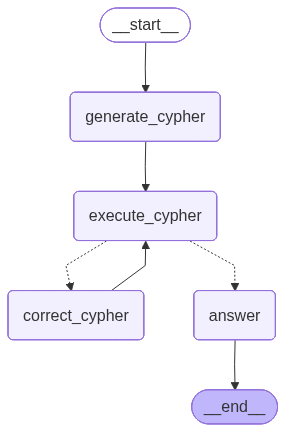

In [22]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [23]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({'messages': [{'role': 'user', 'content': user_input}]}):
        for value in event.values():
            print(value, '\n')

In [24]:
while True:
    try:
        user_input = input('User : ')
        if user_input.lower() in ['quit', 'exit', 'q']:
            print('Goodbye!')
            break

        stream_graph_updates(user_input)
    except:
        break

{'messages': [AIMessage(content="MATCH (a:Actor {name: '공원나연'}) RETURN a", additional_kwargs={}, response_metadata={}, id='966a4ace-277e-4f77-9467-46a4815f320d')]} 

###### EXECUTE CYPHER ######
실행 쿼리문 MATCH (a:Actor {name: '공원나연'}) RETURN a


<ipython-input-11-a28699e8f6ff>:19: DeprecationWarning: read_transaction has been renamed to execute_read
  database_output = session.read_transaction(


###### ROUTE QUERY CORRECTION ######
DB 조회 결과 []
!정상 조회 실패!
{'db_outputs': [[]]} 

###### CORRECT CYPHER ######
수정 전 쿼리문 MATCH (a:Actor {name: '공원나연'}) RETURN a
DB 조회 결과 []
수정 후 쿼리문 RETURN "NO search results found." AS result
{'messages': [AIMessage(content='RETURN "NO search results found." AS result', additional_kwargs={}, response_metadata={}, id='0c194e25-a95b-422f-9e11-3dc99a0dbd01')]} 

###### EXECUTE CYPHER ######
실행 쿼리문 RETURN "NO search results found." AS result


<ipython-input-11-a28699e8f6ff>:19: DeprecationWarning: read_transaction has been renamed to execute_read
  database_output = session.read_transaction(


###### ROUTE QUERY CORRECTION ######
DB 조회 결과 [{'result': 'NO search results found.'}]
!정상 조회 완료!
{'db_outputs': [[{'result': 'NO search results found.'}]]} 

###### ANSWER BASED DB RESULT ######
최종 답변 해당 컨텍스트에 따르면, "공원나연"에 대한 검색 결과가 없다는 메시지가 반환되었습니다. 이는 Neo4j 데이터베이스에서 "공원나연"이라는 이름의 배우 노드가 존재하지 않음을 의미합니다. 따라서, 현재의 데이터베이스에 "공원나연"에 대한 정보가 없다는 결론을 내릴 수 있습니다. 추가적인 정보를 원하신다면, 데이터베이스에 다른 이름이나 속성으로 저장되어 있는지 확인하거나, 데이터베이스가 최신인지 확인하는 것이 필요할 수 있습니다.
{'messages': [AIMessage(content='해당 컨텍스트에 따르면, "공원나연"에 대한 검색 결과가 없다는 메시지가 반환되었습니다. 이는 Neo4j 데이터베이스에서 "공원나연"이라는 이름의 배우 노드가 존재하지 않음을 의미합니다. 따라서, 현재의 데이터베이스에 "공원나연"에 대한 정보가 없다는 결론을 내릴 수 있습니다. 추가적인 정보를 원하신다면, 데이터베이스에 다른 이름이나 속성으로 저장되어 있는지 확인하거나, 데이터베이스가 최신인지 확인하는 것이 필요할 수 있습니다.', additional_kwargs={}, response_metadata={}, id='0c92e2c1-6b4b-44bb-8399-5447c60186ec')]} 

Goodbye!


In [25]:
while True:
    try:
        user_input = input('User : ')
        if user_input.lower() in ['quit', 'exit', 'q']:
            print('Goodbye!')
            break

        stream_graph_updates(user_input)
    except:
        break

{'messages': [AIMessage(content="MATCH (a:Actor {name: 'Tom Hanks'})-[:ACTED_IN]->(m:Movie) RETURN m.title LIMIT 3", additional_kwargs={}, response_metadata={}, id='c4431337-06d0-4057-96f8-bb14d65068a7')]} 

###### EXECUTE CYPHER ######
실행 쿼리문 MATCH (a:Actor {name: 'Tom Hanks'})-[:ACTED_IN]->(m:Movie) RETURN m.title LIMIT 3


<ipython-input-11-a28699e8f6ff>:19: DeprecationWarning: read_transaction has been renamed to execute_read
  database_output = session.read_transaction(


###### ROUTE QUERY CORRECTION ######
DB 조회 결과 [{'m.title': 'Punchline'}, {'m.title': 'Catch Me If You Can'}, {'m.title': 'Dragnet'}]
!정상 조회 완료!
{'db_outputs': [[{'m.title': 'Punchline'}, {'m.title': 'Catch Me If You Can'}, {'m.title': 'Dragnet'}]]} 

###### ANSWER BASED DB RESULT ######
최종 답변 Tom Hanks가 출연한 영화 3개는 'Punchline', 'Catch Me If You Can', 'Dragnet'입니다. 이 정보는 제공된 컨텍스트에 기반한 결과입니다.
{'messages': [AIMessage(content="Tom Hanks가 출연한 영화 3개는 'Punchline', 'Catch Me If You Can', 'Dragnet'입니다. 이 정보는 제공된 컨텍스트에 기반한 결과입니다.", additional_kwargs={}, response_metadata={}, id='42e3b9e0-aef9-48f2-874b-91c7050653c6')]} 

{'messages': [AIMessage(content="MATCH (a:Actor)-[:ACTED_IN]->(m:Movie) WHERE a.name = '레오나르도 디카프리오' RETURN m.title LIMIT 2", additional_kwargs={}, response_metadata={}, id='83adea3f-cff8-4cd9-82f8-79c0b5fc3261')]} 

###### EXECUTE CYPHER ######
실행 쿼리문 MATCH (a:Actor)-[:ACTED_IN]->(m:Movie) WHERE a.name = '레오나르도 디카프리오' RETURN m.title LIMIT 2


<ipython-input-11-a28699e8f6ff>:19: DeprecationWarning: read_transaction has been renamed to execute_read
  database_output = session.read_transaction(


###### ROUTE QUERY CORRECTION ######
DB 조회 결과 []
!정상 조회 실패!
{'db_outputs': [[]]} 

###### CORRECT CYPHER ######
수정 전 쿼리문 MATCH (a:Actor)-[:ACTED_IN]->(m:Movie) WHERE a.name = '레오나르도 디카프리오' RETURN m.title LIMIT 2
DB 조회 결과 []
수정 후 쿼리문 RETURN "NO search results found." AS result
{'messages': [AIMessage(content='RETURN "NO search results found." AS result', additional_kwargs={}, response_metadata={}, id='c80d6206-cc3d-4bd8-9c22-094b9d040cae')]} 

###### EXECUTE CYPHER ######
실행 쿼리문 RETURN "NO search results found." AS result


<ipython-input-11-a28699e8f6ff>:19: DeprecationWarning: read_transaction has been renamed to execute_read
  database_output = session.read_transaction(


###### ROUTE QUERY CORRECTION ######
DB 조회 결과 [{'result': 'NO search results found.'}]
!정상 조회 완료!
{'db_outputs': [[{'result': 'NO search results found.'}]]} 

###### ANSWER BASED DB RESULT ######
최종 답변 현재 제공된 컨텍스트에 따르면, "레오나르도 디카프리오가 출연한 영화 2개"에 대한 검색 결과가 없습니다. 이는 Neo4j 데이터베이스에서 해당 정보를 찾지 못했음을 의미합니다.

질문에 답하기 위해서는 데이터베이스에 레오나르도 디카프리오와 관련된 영화 정보가 저장되어 있어야 하며, 검색 쿼리가 정확하게 데이터베이스에서 결과를 반환할 수 있도록 구성되어야 합니다. 데이터베이스에 레오나르도 디카프리오의 영화가 제대로 입력되어 있는지, 쿼리가 정확한지 확인이 필요합니다.
{'messages': [AIMessage(content='현재 제공된 컨텍스트에 따르면, "레오나르도 디카프리오가 출연한 영화 2개"에 대한 검색 결과가 없습니다. 이는 Neo4j 데이터베이스에서 해당 정보를 찾지 못했음을 의미합니다.\n\n질문에 답하기 위해서는 데이터베이스에 레오나르도 디카프리오와 관련된 영화 정보가 저장되어 있어야 하며, 검색 쿼리가 정확하게 데이터베이스에서 결과를 반환할 수 있도록 구성되어야 합니다. 데이터베이스에 레오나르도 디카프리오의 영화가 제대로 입력되어 있는지, 쿼리가 정확한지 확인이 필요합니다.', additional_kwargs={}, response_metadata={}, id='7d2f19f6-43c8-4ce3-a513-3174ec97dfcf')]} 

Goodbye!


In [26]:
while True:
    try:
        user_input = input('User : ')
        if user_input.lower() in ['quit', 'exit', 'q']:
            print('Goodbye!')
            break

        stream_graph_updates(user_input)
    except:
        break

{'messages': [AIMessage(content="MATCH (d:Director)-[:DIRECTED]->(m:Movie)-[:IN_GENRE]->(g:Genre) \nWHERE d.name = 'Steven Spielberg' \nRETURN DISTINCT g.name", additional_kwargs={}, response_metadata={}, id='d665de32-5044-4cec-9580-dec94758a39c')]} 

###### EXECUTE CYPHER ######
실행 쿼리문 MATCH (d:Director)-[:DIRECTED]->(m:Movie)-[:IN_GENRE]->(g:Genre) 
WHERE d.name = 'Steven Spielberg' 
RETURN DISTINCT g.name


<ipython-input-11-a28699e8f6ff>:19: DeprecationWarning: read_transaction has been renamed to execute_read
  database_output = session.read_transaction(


###### ROUTE QUERY CORRECTION ######
DB 조회 결과 [{'g.name': 'Sci-Fi'}, {'g.name': 'Thriller'}, {'g.name': 'Fantasy'}, {'g.name': 'Horror'}, {'g.name': 'Comedy'}, {'g.name': 'Adventure'}, {'g.name': 'Action'}, {'g.name': 'Drama'}, {'g.name': 'Mystery'}, {'g.name': 'War'}, {'g.name': 'Romance'}, {'g.name': 'Children'}, {'g.name': 'Crime'}, {'g.name': 'IMAX'}, {'g.name': 'Animation'}]
!정상 조회 완료!
{'db_outputs': [[{'g.name': 'Sci-Fi'}, {'g.name': 'Thriller'}, {'g.name': 'Fantasy'}, {'g.name': 'Horror'}, {'g.name': 'Comedy'}, {'g.name': 'Adventure'}, {'g.name': 'Action'}, {'g.name': 'Drama'}, {'g.name': 'Mystery'}, {'g.name': 'War'}, {'g.name': 'Romance'}, {'g.name': 'Children'}, {'g.name': 'Crime'}, {'g.name': 'IMAX'}, {'g.name': 'Animation'}]]} 

###### ANSWER BASED DB RESULT ######
최종 답변 스티븐 스필버그 감독은 다음과 같은 장르의 영화를 만들었습니다: SF, 스릴러, 판타지, 공포, 코미디, 모험, 액션, 드라마, 미스터리, 전쟁, 로맨스, 어린이, 범죄, IMAX, 애니메이션.
{'messages': [AIMessage(content='스티븐 스필버그 감독은 다음과 같은 장르의 영화를 만들었습니다: SF, 스릴러, 판타지, 공포, 코미디, 모험, 액

<ipython-input-11-a28699e8f6ff>:19: DeprecationWarning: read_transaction has been renamed to execute_read
  database_output = session.read_transaction(


###### ROUTE QUERY CORRECTION ######
DB 조회 결과 [{'coActor.name': 'Tim Allen', 'appearances': 4}, {'coActor.name': 'Joan Cusack', 'appearances': 3}, {'coActor.name': 'Rita Wilson', 'appearances': 2}]
!정상 조회 완료!
{'db_outputs': [[{'coActor.name': 'Tim Allen', 'appearances': 4}, {'coActor.name': 'Joan Cusack', 'appearances': 3}, {'coActor.name': 'Rita Wilson', 'appearances': 2}]]} 

###### ANSWER BASED DB RESULT ######
최종 답변 Tom Hanks와 같은 영화에 가장 많이 출연한 배우 3명은 다음과 같습니다:

1. Tim Allen - 함께 출연한 횟수: 4회
2. Joan Cusack - 함께 출연한 횟수: 3회
3. Rita Wilson - 함께 출연한 횟수: 2회

이 정보는 제공된 컨텍스트에서 확인되었습니다.
{'messages': [AIMessage(content='Tom Hanks와 같은 영화에 가장 많이 출연한 배우 3명은 다음과 같습니다:\n\n1. Tim Allen - 함께 출연한 횟수: 4회\n2. Joan Cusack - 함께 출연한 횟수: 3회\n3. Rita Wilson - 함께 출연한 횟수: 2회\n\n이 정보는 제공된 컨텍스트에서 확인되었습니다.', additional_kwargs={}, response_metadata={}, id='be73affe-8ed8-4908-958c-7b7177619a7b')]} 

Goodbye!
